# Worksheet 4 - Mathematical morphology (TPI.3)

## Informação Geral

#### **Autores**
- Ivo Filipe Carvalho de Sá, a22604
- Diogo Sousa Gomes, a22588

#### Notes:
- The purpose of this worksheet is to implement the concepts learned in the Biomedical Image Processing - Mathematical morphology 
- The resolution of the exercises of this practical work must be sent by email with the name "PIB_GroupNumber_TPI.3"
- The images to be used are available in the curricular unit's moodle - "Worksheet images"

## Bibliotecas Utilizadas

In [1]:
# ==========================================================
# BIBLIOTECAS UTILIZADAS
# ==========================================================

# ----------------------
# Computação Numérica
# ----------------------
# NumPy
# Biblioteca fundamental para operações numéricas e manipulação
# de arrays multidimensionais (ex: imagens).
import numpy as np


# ----------------------
# Sistema e Manipulação de Dados
# ----------------------
# os
# Permite interação com o sistema de ficheiros (diretórios, caminhos, etc.).
import os

# io
# Manipulação de fluxos binários em memória (ex: conversão de bytes para imagem).
import io


# ----------------------
# Visualização de Dados
# ----------------------
# Matplotlib
# Utilizado para apresentação de imagens e gráficos.
import matplotlib.pyplot as plt        # Visualização geral
import matplotlib.image as mpimg       # Leitura de imagens

# Ativação da renderização inline no Jupyter Notebook
%matplotlib inline


# ----------------------
# Processamento de Imagem (scikit-image)
# ----------------------

# Módulos principais
from skimage import measure            # Análise de regiões
from skimage import morphology         # Operações morfológicas

# Alias para operações morfológicas (facilita uso)
import skimage.morphology as mf


# ----------------------
# Operações Morfológicas Específicas
# ----------------------

# Transformações básicas sobre objetos binários

from skimage.morphology import (
    erosion,       # Reduz objetos (remove pixels das bordas)
    dilation,      # Expande objetos
    opening,       # Erosão seguida de dilatação (remove ruído)
    closing,       # Dilatação seguida de erosão (preenche falhas)
    disk           # Elemento estruturante circular
)


# ----------------------
# Rotulagem e Análise de Regiões
# ----------------------

# label: identifica regiões conectadas
# regionprops: extrai propriedades (área, perímetro, etc.)
from skimage.measure import label, regionprops


# ----------------------
# Interação com o Utilizador (Jupyter)
# ----------------------

# ipywidgets
# Criação de componentes interativos (ex: upload de imagens)
import ipywidgets as widgets

# display
# Permite apresentar widgets e outputs visuais
from IPython.display import display

## Funções Gerais

### Funções de Processamento

#### Função de Verificação de Compatiblidade
> - Verifica se a imagem e a mascara correspondente contém a mesma dimensão

In [4]:
# ==========================================================
# FUNÇÃO: VERIFICAR DIMENSÕES ENTRE IMAGEM E MÁSCARA
# ==========================================================

def validar_dimensoes(img, mask=None):
    """
    Verifica se a imagem e a máscara têm as mesmas dimensões.
    Caso não exista máscara, assume-se válida.

    Parâmetros:
        img (ndarray): imagem original
        mask (ndarray, opcional): máscara associada

    Retorna:
        bool: True se compatível ou sem máscara
              False caso contrário
    """

    # ==========================================================
    # 1. VERIFICAR SE EXISTE MÁSCARA
    # ==========================================================

    # Se não for fornecida máscara, não há nada para comparar
    # Logo, considera-se válido
    if mask is None:
        return True


    # ==========================================================
    # 2. OBTER DIMENSÕES DA IMAGEM
    # ==========================================================

    # Extrai altura e largura da imagem
    # [:2] ignora canais (ex: RGB)
    img_h, img_w = img.shape[:2]


    # ==========================================================
    # 3. OBTER DIMENSÕES DA MÁSCARA
    # ==========================================================

    # Extrai altura e largura da máscara
    mask_h, mask_w = mask.shape[:2]


    # ==========================================================
    # 4. COMPARAR DIMENSÕES
    # ==========================================================

    # Verifica se altura e largura são iguais
    if img_h == mask_h and img_w == mask_w:
        return True  # Compatíveis


    # ==========================================================
    # 5. RESULTADO FINAL
    # ==========================================================

    # Caso exista máscara mas dimensões não coincidam
    return False

#### Função de Conversão dtype
> - Verifica qual o formato da imagem
> - Converte quando necessário, a imagem para uint8

In [5]:
# ==========================================================
# FUNÇÃO: CONVERSÃO DE IMAGEM PARA uint8
# ==========================================================

def to_uint8(img):
    """
    Converte uma imagem para o formato uint8 (0–255).

    Parâmetros:
        img (ndarray): imagem de entrada

    Retorna:
        ndarray: imagem no formato uint8
    """

    # ==========================================================
    # 1. VERIFICAR O TIPO ATUAL
    # ==========================================================

    # Se a imagem já estiver no formato uint8,
    # não é necessário qualquer conversão
    if img.dtype == np.uint8:
        return img


    # ==========================================================
    # 2. NORMALIZAÇÃO DOS VALORES
    # ==========================================================

    # Muitas imagens (ex: após resize ou operações do skimage)
    # estão no intervalo [0, 1], sendo necessário escalar para [0, 255]

    # Obtém valor mínimo da imagem
    img_min = np.min(img)

    # Obtém valor máximo da imagem
    img_max = np.max(img)


    # ==========================================================
    # 3. EVITAR DIVISÃO POR ZERO
    # ==========================================================

    # Caso todos os valores sejam iguais (imagem constante),
    # evita divisão por zero
    if img_max == img_min:
        return np.zeros_like(img, dtype=np.uint8)


    # ==========================================================
    # 4. ESCALONAMENTO PARA [0, 255]
    # ==========================================================

    # Normaliza para [0,1] e depois escala para [0,255]
    img_scaled = (img - img_min) / (img_max - img_min) * 255


    # ==========================================================
    # 5. CONVERSÃO FINAL DE TIPO
    # ==========================================================

    # Converte os valores para inteiro sem sinal de 8 bits
    img_uint8 = img_scaled.astype(np.uint8)


    # ==========================================================
    # 6. RETORNO
    # ==========================================================

    return img_uint8

#### Função de Conversão de canais
> - Verifica qual o numero de canais atual da imagem
> - Converte, quando necessário, a imagem para grayscale
> - Quando aplicavel, converte a imagem para binário

In [6]:
# ==========================================================
# FUNÇÃO: GRAYSCALE + BINARIZAÇÃO (COM PESOS CORRETOS)
# ==========================================================

def to_gray_binary(img, interval=None):
    """
    Converte uma imagem para grayscale utilizando pesos perceptuais
    e, opcionalmente, aplica binarização com base num intervalo [min, max].

    Suporta:
        - Grayscale
        - RGB
        - RGBA (ignora canal alfa)

    Parâmetros:
        img (ndarray): imagem de entrada
        interval (list/tuple, opcional): [min, max] para binarização

    Retorna:
        ndarray: imagem em grayscale ou binária
    """

    # ==========================================================
    # 1. CONVERSÃO PARA GRAYSCALE (COM PESOS)
    # ==========================================================

    # Se a imagem tiver múltiplos canais
    if img.ndim == 3:

        # Caso tenha canal alfa (RGBA)
        if img.shape[2] == 4:
            # Ignora o canal de transparência
            rgb = img[:, :, :3]
        else:
            # RGB normal
            rgb = img

        # Aplicação dos pesos perceptuais:
        # R = 0.299 | G = 0.587 | B = 0.114
        gray = (
            0.299 * rgb[:, :, 0] +
            0.587 * rgb[:, :, 1] +
            0.114 * rgb[:, :, 2]
        )

    else:
        # Já é grayscale
        gray = img


    # ==========================================================
    # 2. BINARIZAÇÃO OPCIONAL
    # ==========================================================

    # Se não houver intervalo → retorna apenas grayscale
    if interval is None:
        return gray

    # Extrai valores mínimo e máximo
    min_val, max_val = interval


    # ==========================================================
    # 3. CRIAÇÃO DA IMAGEM BINÁRIA
    # ==========================================================

    # Pixels dentro do intervalo → 1 (True)
    # Fora do intervalo → 0 (False)
    binary = (gray >= min_val) & (gray <= max_val)


    # ==========================================================
    # 4. CONVERSÃO PARA FORMATO VISUAL (uint8)
    # ==========================================================

    # True → 255 | False → 0
    binary = binary.astype(np.uint8) * 255


    # ==========================================================
    # 5. RETORNO
    # ==========================================================

    return binary

### Funções de Input/Output

#### Função de Criação de Uploader
> - Cria meio de seleção de imaegens interativo 

In [21]:
# ==========================================================
# FUNÇÃO: CRIAR UPLOADER PERSONALIZADO
# ==========================================================

def criar_uploader(nome="Upload"):
    """
    Cria um widget FileUpload com descrição personalizada.

    Parâmetros:
        nome (str): texto a apresentar no botão

    Retorna:
        FileUpload: widget de upload criado
    """

    # ==========================================================
    # 1. CRIAÇÃO DO WIDGET
    # ==========================================================

    # Cria uploader configurado para imagens
    uploader = widgets.FileUpload(
        accept='image/*',   # Aceita apenas imagens
        multiple=False,     # Apenas um ficheiro
        description=nome    # Nome visível no botão
    )


    # ==========================================================
    # 2. APRESENTAÇÃO NO NOTEBOOK
    # ==========================================================

    # Mostra o botão no Jupyter
    display(uploader)


    # ==========================================================
    # 3. RETORNO
    # ==========================================================

    return uploader

#### Função de Carregamento
> - Responsavel por carregar, analisar e converter as imagens carregadas.
> - Mesmo que a imagem carregada seja binária, a mesma não será afetada pelo logaritmo.

In [34]:
# ==========================================================
# FUNÇÃO: CARREGAR IMAGEM (COM PRÉ-PROCESSAMENTO)
# ==========================================================

def carregar_imagem(upload_widget):
    """
    Carrega uma imagem do uploader e aplica pré-processamento:
    - Conversão para uint8
    - Conversão para grayscale

    Parâmetros:
        upload_widget (FileUpload): widget com ficheiro carregado

    Retorna:
        tuple:
            imagem (ndarray): imagem processada
            nome (str): nome do ficheiro
    """

    # ==========================================================
    # 1. VERIFICAR SE EXISTE FICHEIRO
    # ==========================================================

    if not upload_widget.value:
        return None, None


    # ==========================================================
    # 2. OBTER FICHEIRO
    # ==========================================================

    ficheiro = list(upload_widget.value.values())[0]

    nome = ficheiro['name']
    conteudo = ficheiro['content']


    # ==========================================================
    # 3. CONVERTER PARA IMAGEM (NUMPY)
    # ==========================================================

    img = mpimg.imread(io.BytesIO(conteudo))


    # ==========================================================
    # 4. CONVERSÃO PARA uint8 (FUNÇÃO PRÓPRIA)
    # ==========================================================

    img = to_uint8(img)


    # ==========================================================
    # 5. CONVERSÃO PARA GRAYSCALE (SEM BINARIZAÇÃO)
    # ==========================================================

    img = to_gray_binary(img)  # sem intervalo → só grayscale


    # ==========================================================
    # 6. RETORNO
    # ==========================================================

    return img, nome

## Carregamento de Imagens

In [28]:
# ==========================================================
# QUESTÕES 1 E 2
# ==========================================================

def setup_q1_q2():
    """
    Inicializa uploaders para as questões 1 e 2
    """

    print("Carregue as imagens 'BinaryImg.png' e 'BinaryImg_processed.png' (Q1 e Q2)")

    upload_bin = criar_uploader("BinaryImg")
    upload_proc = criar_uploader("BinaryImg_P")

    return upload_bin, upload_proc


# EXECUÇÃO
upload_bin, upload_proc = setup_q1_q2()

Carregue as imagens 'BinaryImg.png' e 'BinaryImg_processed.png' (Q1 e Q2)


FileUpload(value=(), accept='image/*', description='BinaryImg')

FileUpload(value=(), accept='image/*', description='BinaryImg_P')

In [29]:
# ==========================================================
# QUESTÕES 3, 4 E 5
# ==========================================================

def setup_q3_q5():
    """
    Inicializa uploader para questões 3 a 5
    """

    print("Carregue a imagem 'structures.png' (Q3, Q4 e Q5)")

    upload_struct = criar_uploader("structures")

    return upload_struct


# EXECUÇÃO
upload_struct = setup_q3_q5()

Carregue a imagem 'structures.png' (Q3, Q4 e Q5)


FileUpload(value=(), accept='image/*', description='structures')

In [31]:
# ==========================================================
# QUESTÕES 6, 7 E 8
# ==========================================================

def setup_q6_q8():
    """
    Inicializa uploaders para questões 6 a 8
    """

    print("Carregue as imagens 'brain.png' 'brain_gaussian_noise.png' (Q6, Q7 e Q8)")

    upload_brain = criar_uploader("brain")
    upload_noise = criar_uploader("brain_g_n")

    return upload_brain, upload_noise


# EXECUÇÃO
upload_brain, upload_noise = setup_q6_q8()

Carregue as imagens 'brain.png' 'brain_gaussian_noise.png' (Q6, Q7 e Q8)


FileUpload(value=(), accept='image/*', description='brain')

FileUpload(value=(), accept='image/*', description='brain_g_n')

In [32]:
# ==========================================================
# QUESTÕES 9, 10 E 11
# ==========================================================

def setup_q9_q11():
    """
    Inicializa uploaders para questões 9 a 11
    """

    print("Carregue as imagens 'kidney.png' 'kidney_segmented.png' (Q9, Q10 e Q11)")

    upload_kidney = criar_uploader("Kidney")
    upload_mask = criar_uploader("kidney_segmented")

    return upload_kidney, upload_mask


# EXECUÇÃO
upload_kidney, upload_mask = setup_q9_q11()

Carregue as imagens 'kidney.png' 'kidney_segmented.png' (Q9, Q10 e Q11)


FileUpload(value=(), accept='image/*', description='Kidney')

FileUpload(value=(), accept='image/*', description='kidney_segmented')

## Questões Propostas

### Question 1: 
> - Read and visualize the "BinaryImg.png" image and its processed version "BinaryImg_processed.png".
>
> - You must view the images side by side (horizontally)

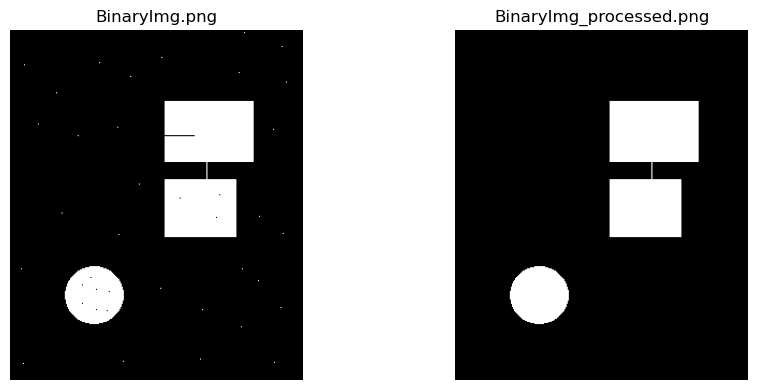

In [39]:
# ----------------------
# CARREGAR IMAGENS
# ----------------------

img_bin, nome_bin = carregar_imagem(upload_bin)
img_proc, nome_proc = carregar_imagem(upload_proc)


# ----------------------
# VERIFICAÇÃO
# ----------------------

if img_bin is None or img_proc is None:
    print("Erro: carregue ambas as imagens.")

else:

    # Verificação opcional dos nomes (alinhado com enunciado)
    if nome_bin != "BinaryImg.png" or nome_proc != "BinaryImg_processed.png":
        print("Aviso: os nomes dos ficheiros não correspondem ao enunciado.")


    # ----------------------
    # VISUALIZAÇÃO LADO A LADO
    # ----------------------

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Imagem original
    ax1.imshow(img_bin, cmap='gray')
    ax1.set_title("BinaryImg.png")
    ax1.axis('off')

    # Imagem processada
    ax2.imshow(img_proc, cmap='gray')
    ax2.set_title("BinaryImg_processed.png")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

#### Observações

> - A imagem original apresenta ruído e pequenos pontos isolados/invertidos.
> - Esses artefactos reduzem a uniformidade das estruturas.
> - A imagem processada não apresenta esses ruídos.
> - As regiões tornam-se mais limpas e contínuas após o processamento.

### Question 2: 
> Use the concepts of mathematical morphology to obtain the image "BinaryImg_processed.png" from the image ""BinaryImg.png".

Elemento estruturante vertical:
 [[0 1 0]
 [0 1 0]
 [0 1 0]]
Elemento estruturante quadrado:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


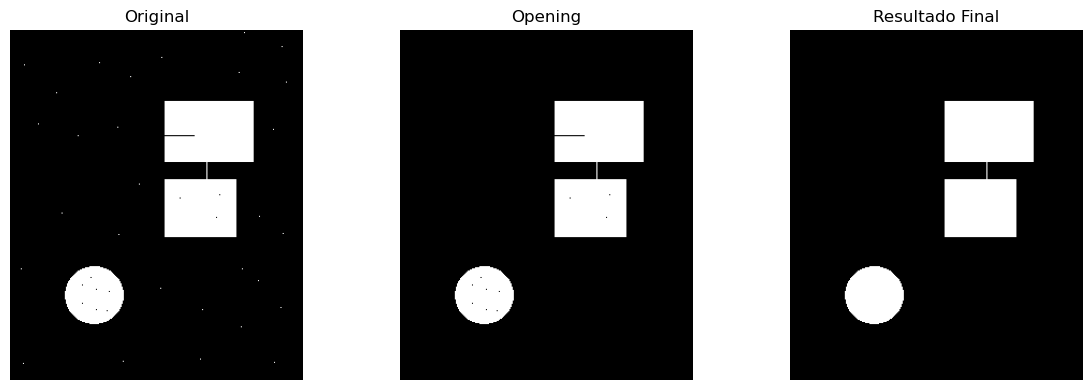

In [44]:
# ----------------------
# ELEMENTOS ESTRUTURANTES
# ----------------------

# Define um elemento estruturante vertical (3x3)
El_es_V = np.array([
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0]
])

# Define um elemento estruturante quadrado (3x3)
El_es_Q = np.ones((3, 3))


# Mostra os elementos estruturantes
print("Elemento estruturante vertical:\n", El_es_V)
print("Elemento estruturante quadrado:\n", El_es_Q)


# ----------------------
# OPERAÇÕES MORFOLÓGICAS
# ----------------------

# Aplica a operação de opening à imagem original
img_open = mf.opening(img_bin, El_es_V)

# Aplica a operação de closing ao resultado do opening
img_result = mf.closing(img_open, El_es_Q)


# ----------------------
# VISUALIZAÇÃO
# ----------------------

# Cria uma figura com 3 subplots lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))


# Mostra a imagem original
ax1.imshow(img_bin, cmap='gray')
ax1.set_title("Original")
ax1.axis('off')


# Mostra o resultado do opening
ax2.imshow(img_open, cmap='gray')
ax2.set_title("Opening")
ax2.axis('off')


# Mostra o resultado final (closing)
ax3.imshow(img_result, cmap='gray')
ax3.set_title("Resultado Final")
ax3.axis('off')


# Ajusta o layout
plt.tight_layout()

# Apresenta a figura
plt.show()

#### Observações

> - A operação de *opening* remove pequenas regiões e ruído da imagem.
> - A operação de *closing* preenche lacunas e liga regiões próximas.
> - A combinação das duas operações melhora a continuidade das estruturas.
> - O resultado final aproxima-se da imagem binária processada fornecida.

### Question 3: 
> Read and visualize the "structures.png".

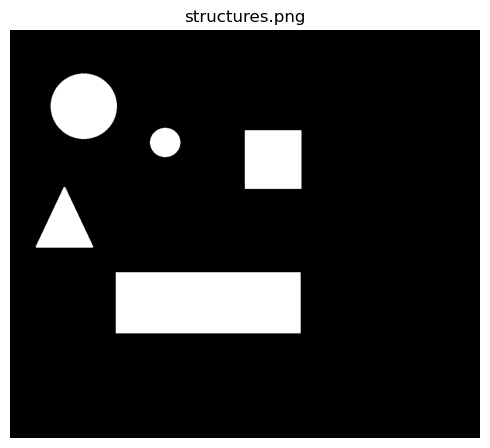

In [45]:
# ----------------------
# CARREGAR IMAGEM
# ----------------------

img_struct, nome_struct = carregar_imagem(upload_struct)


# ----------------------
# VERIFICAÇÃO
# ----------------------

if img_struct is None:
    print("Erro: carregue a imagem 'structures.png'.")

else:

    # Aviso opcional (nome do ficheiro)
    if nome_struct != "structures.png":
        print("Aviso: o nome do ficheiro não corresponde ao enunciado.")


    # ----------------------
    # VISUALIZAÇÃO
    # ----------------------

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.imshow(img_struct, cmap='gray')
    ax.set_title("structures.png")
    ax.axis('off')

    plt.tight_layout()
    plt.show()

#### Observações

> - A imagem é binária, com alto contraste entre objetos e fundo.
> - Contém várias formas geométricas distintas e bem definidas.
> - As estruturas apresentam diferentes tamanhos e estão bem separadas.
> - Não se observa ruído significativo.

### Question 4: 
>Generate an binary image containing the contours of the objects. 

Elemento estruturante:
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


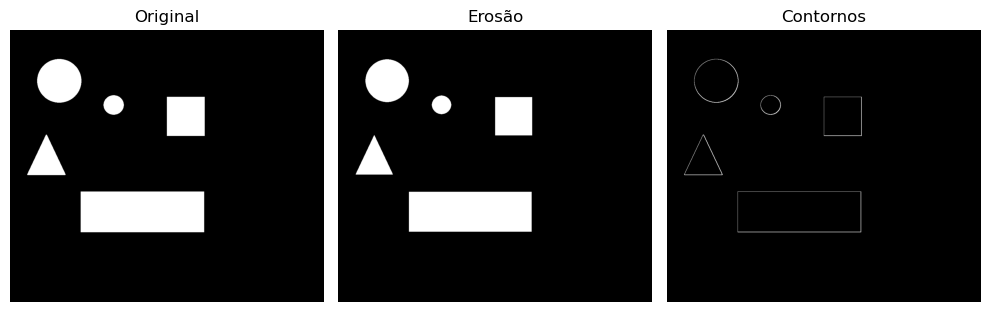

In [47]:
# ==========================================================
# QUESTION 4
# ==========================================================

# ----------------------
# ELEMENTO ESTRUTURANTE
# ----------------------

# Define elemento estruturante quadrado (4x4)
elemento_estruturante = np.ones((4, 4))

print("Elemento estruturante:\n", elemento_estruturante)


# ----------------------
# EROSÃO
# ----------------------

# Aplica erosão à imagem
img_erosao = erosion(img_struct, elemento_estruturante)


# ----------------------
# CONTORNOS (A - (A - B))
# ----------------------

# Subtrai a imagem erodida à original
img_contornos = img_struct - img_erosao


# ----------------------
# VISUALIZAÇÃO
# ----------------------

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

# Original
ax1.imshow(img_struct, cmap='gray')
ax1.set_title("Original")
ax1.axis('off')

# Erosão
ax2.imshow(img_erosao, cmap='gray')
ax2.set_title("Erosão")
ax2.axis('off')

# Contornos
ax3.imshow(img_contornos, cmap='gray')
ax3.set_title("Contornos")
ax3.axis('off')

plt.tight_layout()
plt.show()

#### Observações

> - A erosão reduz as estruturas, removendo os pixels das suas fronteiras.
> - A subtração entre a imagem original e a erodida isola apenas os contornos.
> - O resultado evidencia as bordas das formas, eliminando o interior dos objetos.
>- Os contornos obtidos são finos e bem definidos, correspondendo às fronteiras das estruturas.

### Question 5: 
> - Use the labelling to differentiate the objects of the image.
> - You must obtain one image per object.

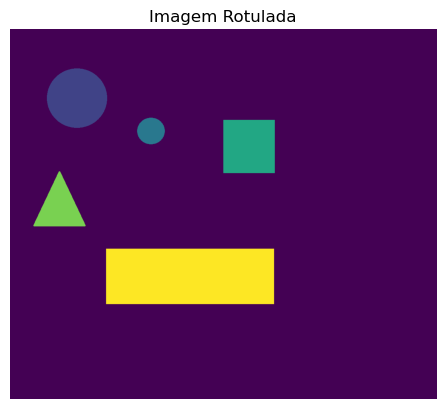

In [67]:
# ==========================================================
# ROTULAGEM
# ==========================================================

# Aplicação do labeling à imagem binária
label_img = label(img_struct)

# Visualização da imagem rotulada
plt.imshow(label_img)
plt.title("Imagem Rotulada")
plt.axis('off')
plt.show()

In [68]:
# ==========================================================
# CLASSIFICAÇÃO DOS OBJETOS
# ==========================================================

# Obtém propriedades de cada região identificada na imagem rotulada
regions = regionprops(label_img)

# Contador para identificar cada objeto (label)
count = 1

# Variáveis para guardar o índice de cada tipo de objeto
index_t = 0      # triângulo
index_r = 0      # retângulo
index_q = 0      # quadrado
index_c_p = 0    # círculo pequeno
index_c_g = 0    # círculo grande

# Listas auxiliares para guardar índices e áreas dos círculos
array_circle = []
array_circle_area = []

# Percorre todas as regiões (objetos) identificadas
for props in regions:

    # Extrai a excentricidade (forma da região)
    eccentricity = props.eccentricity

    # Extrai a área da região (número de pixels)
    area = props.area

    # Área da bounding box (retângulo envolvente)
    bbox_area = props.area_bbox

    # Comprimento do eixo maior (multiplicado por 2)
    axis_major_length = props.axis_major_length * 2

    # Comprimento do eixo menor (multiplicado por 2)
    axis_minor_length = props.axis_minor_length * 2

    # Caso a área da bounding box seja igual à área da região
    # significa que a forma ocupa totalmente o retângulo → quadrado ou retângulo
    if bbox_area == area:

        # Se os eixos forem semelhantes → forma aproximadamente quadrada
        if abs(axis_major_length - axis_minor_length) < 25:
            index_q = count  # guarda índice do quadrado

        else:
            index_r = count  # guarda índice do retângulo

    else:
        # Caso não ocupe totalmente a bounding box → círculo ou triângulo

        # Baixa excentricidade → forma circular
        if eccentricity < 0.5:
            array_circle.append(count)      # guarda índice do círculo
            array_circle_area.append(area)  # guarda área do círculo

        else:
            index_t = count  # guarda índice do triângulo

    # Incrementa contador para próxima região
    count += 1


# ----------------------
# IDENTIFICAÇÃO DOS CÍRCULOS
# ----------------------

# Seleciona o círculo com menor área → círculo pequeno
index_c_p = array_circle[np.argmin(array_circle_area)]

# Seleciona o círculo com maior área → círculo grande
index_c_g = array_circle[np.argmax(array_circle_area)]

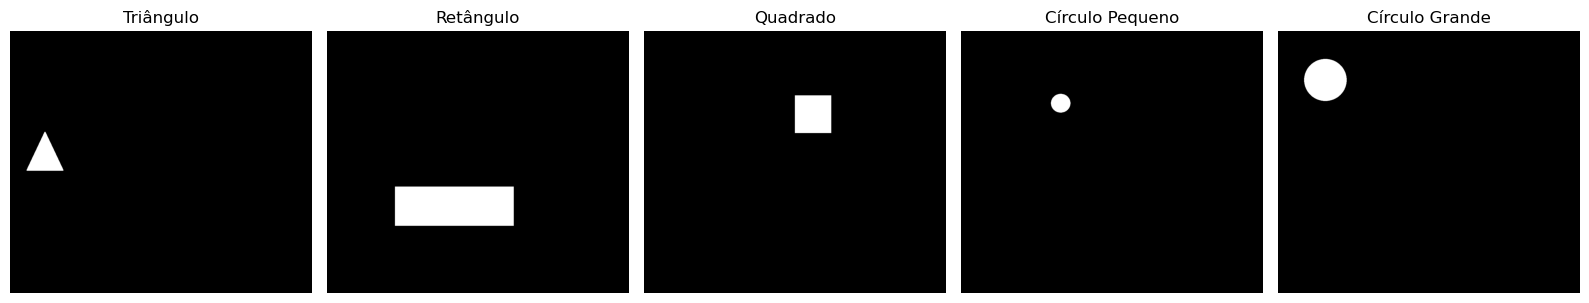

In [69]:
# ==========================================================
# EXTRAÇÃO E VISUALIZAÇÃO
# ==========================================================

# Criação das máscaras
t = label_img == index_t
r = label_img == index_r
q = label_img == index_q
c_p = label_img == index_c_p
c_g = label_img == index_c_g

# Visualização dos objetos
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 4))

ax1.imshow(t, cmap='gray')
ax1.set_title("Triângulo")
ax1.axis('off')

ax2.imshow(r, cmap='gray')
ax2.set_title("Retângulo")
ax2.axis('off')

ax3.imshow(q, cmap='gray')
ax3.set_title("Quadrado")
ax3.axis('off')

ax4.imshow(c_p, cmap='gray')
ax4.set_title("Círculo Pequeno")
ax4.axis('off')

ax5.imshow(c_g, cmap='gray')
ax5.set_title("Círculo Grande")
ax5.axis('off')

plt.tight_layout()
plt.show()

#### Observações

> - A operação de *labeling* permite identificar e separar cada objeto da imagem.
> - Através das propriedades geométricas, é possível distinguir as diferentes formas.
> - Foram geradas máscaras individuais, correspondendo a um objeto por imagem.
> - Cada estrutura é isolada corretamente, permitindo a sua análise independente.

### Question 6: 
> - Read and visualize the "brain.png" and "brain_gaussian_noise.png".
> - You must view the images side by side (horizontally)

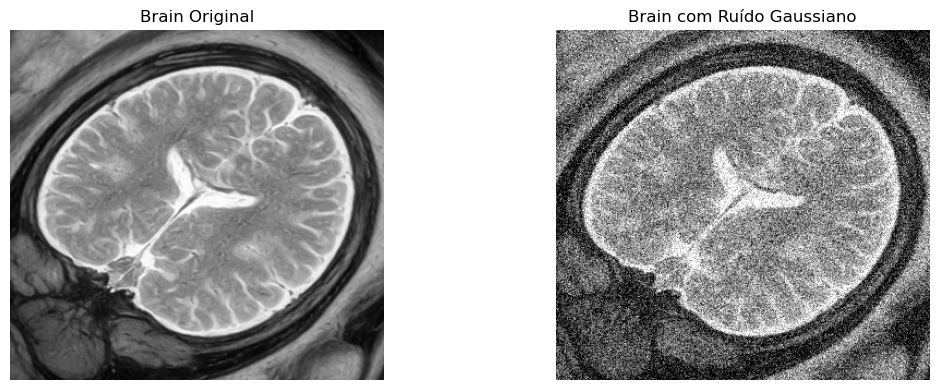

In [70]:
# ----------------------
# CARREGAR IMAGENS
# ----------------------

img_brain, nome_brain = carregar_imagem(upload_brain)
img_noise, nome_noise = carregar_imagem(upload_noise)


# ----------------------
# VERIFICAÇÃO
# ----------------------

if img_brain is None or img_noise is None:
    print("Erro: carregue ambas as imagens.")

else:

    # ----------------------
    # VISUALIZAÇÃO
    # ----------------------

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(img_brain, cmap='gray')
    ax1.set_title("Brain Original")
    ax1.axis('off')

    ax2.imshow(img_noise, cmap='gray')
    ax2.set_title("Brain com Ruído Gaussiano")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

#### Observações

> - A imagem original apresenta boa definição e níveis de intensidade suaves.
> - A imagem com ruído gaussiano apresenta granulação distribuída por toda a imagem.
> - O ruído afeta a perceção das estruturas, reduzindo a sua nitidez.
> - As regiões tornam-se menos homogéneas, dificultando a análise direta.

### Question 7: 
> - Smooth the image "brain_gaussian_noise" using mathematical morphology.
> - Analyze the resulting opening and closing images, as well as the final image. Try different kernel sizes for a disk structuring element.

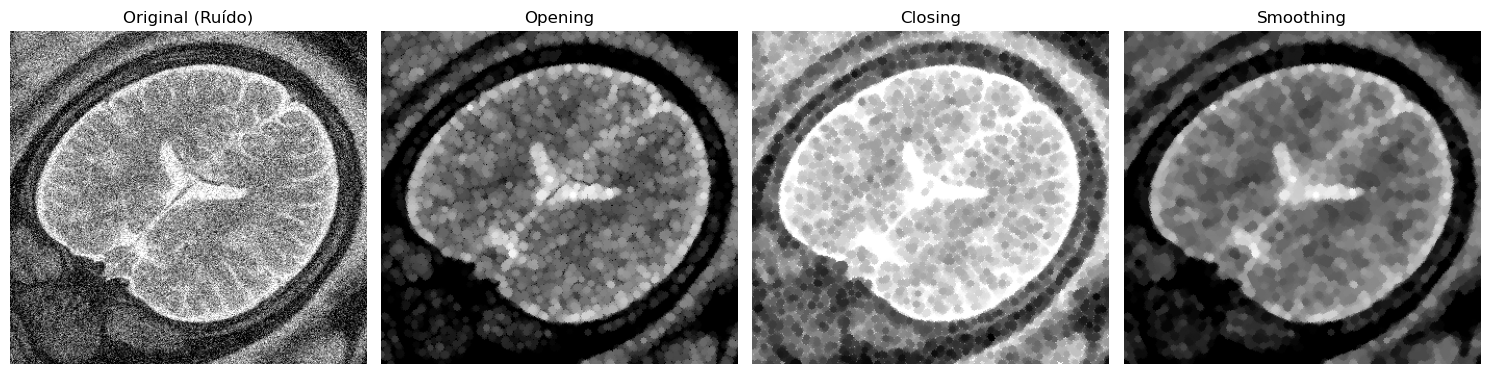

In [73]:
# ----------------------
# ELEMENTO ESTRUTURANTE
# ----------------------

# Define raio do elemento estruturante (disco)
raio = 3

# Cria elemento estruturante circular
K_disk = disk(raio)


# ----------------------
# OPERAÇÕES MORFOLÓGICAS
# ----------------------

# Opening → suavização removendo ruído fino
img_open = opening(img_noise, K_disk)

# Closing → suavização preenchendo pequenas lacunas
img_close = closing(img_noise, K_disk)

# Opening seguido de Closing → smoothing completo
img_smooth = closing(opening(img_noise, K_disk), K_disk)


# ----------------------
# VISUALIZAÇÃO
# ----------------------

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 5))

# Imagem com ruído
ax1.imshow(img_noise, cmap='gray')
ax1.set_title('Original (Ruído)')
ax1.axis('off')

# Opening
ax2.imshow(img_open, cmap='gray')
ax2.set_title('Opening')
ax2.axis('off')

# Closing
ax3.imshow(img_close, cmap='gray')
ax3.set_title('Closing')
ax3.axis('off')

# Resultado final
ax4.imshow(img_smooth, cmap='gray')
ax4.set_title('Smoothing')
ax4.axis('off')

plt.tight_layout()
plt.show()

#### Observações

> - A operação de *opening* reduz o ruído mais fino, suavizando regiões claras.
> - A operação de *closing* atenua lacunas escuras, tornando as regiões mais contínuas.
> - A combinação (*opening* seguido de *closing*) produz uma imagem mais homogénea.
> - O aumento do tamanho do elemento estruturante intensifica a suavização, mas pode levar à perda de detalhe.

### Question 8: 
> - Detect the image contours using mathematical morphology.
> - Apply the edge detection method to the original image and the resulting smoothed images in question 7. Analyze the results.

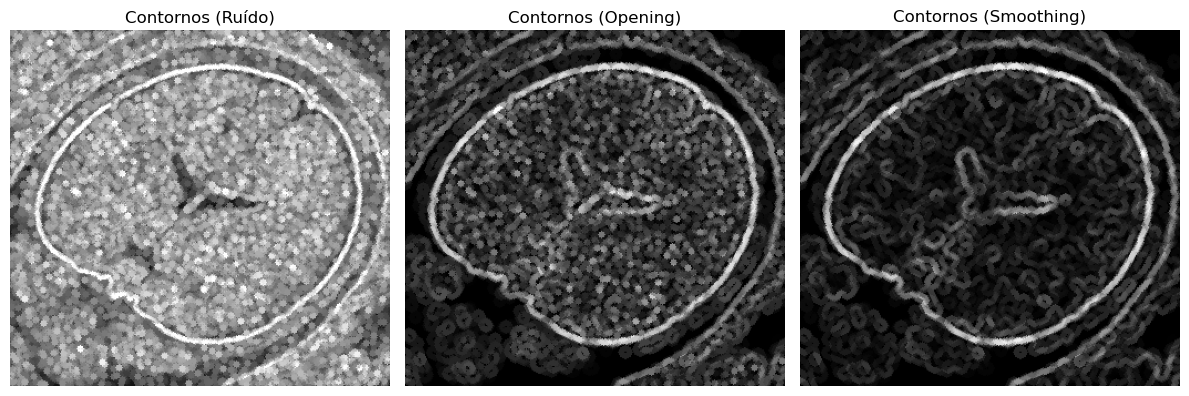

In [75]:
# ----------------------
# ELEMENTO ESTRUTURANTE
# ----------------------

raio = 3
K_disk = disk(raio)


# ----------------------
# CONTORNOS (GRADIENTE MORFOLÓGICO)
# ----------------------

# Contornos da imagem original com ruído
cont_noise = dilation(img_noise, K_disk) - erosion(img_noise, K_disk)

# Contornos após opening
cont_open = dilation(img_open, K_disk) - erosion(img_open, K_disk)

# Contornos após smoothing
cont_smooth = dilation(img_smooth, K_disk) - erosion(img_smooth, K_disk)


# ----------------------
# VISUALIZAÇÃO
# ----------------------

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.imshow(cont_noise, cmap='gray')
ax1.set_title("Contornos (Ruído)")
ax1.axis('off')

ax2.imshow(cont_open, cmap='gray')
ax2.set_title("Contornos (Opening)")
ax2.axis('off')

ax3.imshow(cont_smooth, cmap='gray')
ax3.set_title("Contornos (Smoothing)")
ax3.axis('off')

plt.tight_layout()
plt.show()

#### Observações

> - A deteção de contornos na imagem com ruído apresenta irregularidades e bordas menos definidas.
> - Após *opening*, os contornos tornam-se mais suaves, com redução de ruído fino.
> - A imagem suavizada apresenta contornos mais contínuos e bem definidos.
> - O pré-processamento melhora significativamente a qualidade da deteção de bordas.

### Question 9: 
> - Read and visualize the "kidney.png" and its mask "kidney_segmented.png".
> - You must view the images side by side (horizontally)

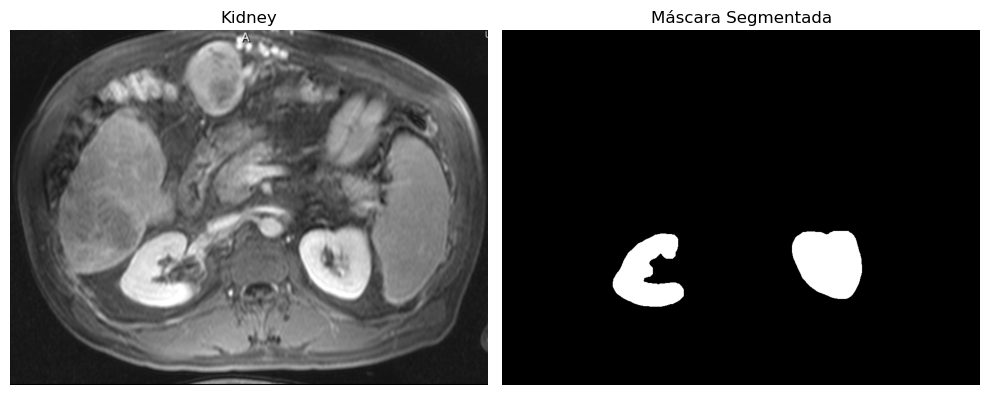

In [77]:
# ----------------------
# CARREGAR IMAGENS
# ----------------------

img_kidney, nome_kidney = carregar_imagem(upload_kidney)
img_mask, nome_mask = carregar_imagem(upload_mask)


# ----------------------
# VERIFICAÇÃO
# ----------------------

if img_kidney is None or img_mask is None:
    print("Erro: carregue ambas as imagens.")

else:

    # ----------------------
    # VISUALIZAÇÃO
    # ----------------------

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Imagem original
    ax1.imshow(img_kidney, cmap='gray')
    ax1.set_title("Kidney")
    ax1.axis('off')

    # Máscara
    ax2.imshow(img_mask, cmap='gray')
    ax2.set_title("Máscara Segmentada")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

#### Observações

> - A imagem original apresenta várias estruturas anatómicas com diferentes intensidades de cinzento.
> - A máscara segmentada é binária, destacando apenas as regiões correspondentes aos rins.
> - As áreas de interesse estão claramente isoladas do fundo.
> - A segmentação simplifica a análise, focando apenas nas estruturas relevantes.

### Question 10: 
> Construct a pipeline to segment the kidneys in the image. 
> - You should start by binarizing the image using an appropriate threshold 
> - You should choose the threshold according to the intensity of the image and kidneys. To analyze the intensities, you need to compute the histogram > of the image and kidney 
> - The final step is to use mathematical morphology and labelling to obtain a kidney mask similar to the "kidney_segmented.png" image. You will need > to present two versions of the pipeline: 1) only using morphology; 2) using morphology and labelling.

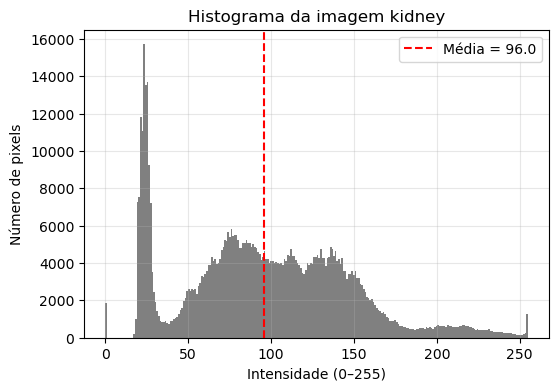

In [121]:
# ==========================================================
# HISTOGRAMA DA IMAGEM
# ==========================================================

plt.figure(figsize=(6,4))

# Flatten da imagem para 1D
plt.hist(img_kidney.ravel(),
         bins=256,
         range=(0,255),
         color='gray')

plt.xlabel('Intensidade (0–255)')
plt.ylabel('Número de pixels')
plt.title('Histograma da imagem kidney')

plt.grid(alpha=0.3)

# Média
media = np.mean(img_kidney)

plt.axvline(media, color='red', linestyle='--', label=f'Média = {media:.1f}')
plt.legend()

plt.show()

In [122]:
# ==========================================================
# BINARIZAÇÃO
# ==========================================================

# Threshold definido manualmente (ajustar conforme histograma)
thres_min = 170
thres_max = 255

# Criação da máscara binária
mask_binaria = (img_kidney >= thres_min) & (img_kidney <= thres_max)

In [123]:
# ==========================================================
# PIPELINE 1 (MORFOLOGIA)
# ==========================================================

# Remoção de ruído
mask_morfologica = morphology.opening(mask_binaria, morphology.disk(3))

# Preenchimento de lacunas
mask_morfologica = morphology.closing(mask_morfologica, morphology.disk(5))

In [124]:
# ==========================================================
# PIPELINE 2 (MORFOLOGIA + LABELING)
# ==========================================================

# Rotulagem
label_img = measure.label(mask_morfologica)

# Extração de propriedades
propriedades = measure.regionprops(label_img)

# Selecionar os 2 maiores objetos (rins)
if len(propriedades) >= 2:

    propriedades.sort(key=lambda x: x.area, reverse=True)

    mask_final = np.zeros_like(mask_morfologica)

    for i in range(2):
        mask_final[label_img == propriedades[i].label] = 1

else:
    mask_final = mask_morfologica

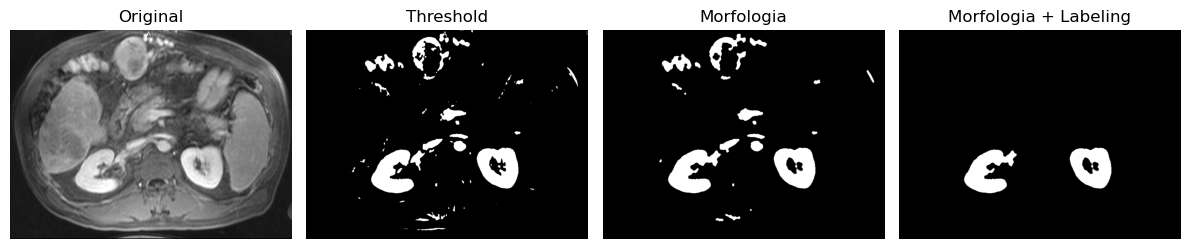

In [125]:
# ==========================================================
# RESULTADOS
# ==========================================================

plt.figure(figsize=(12, 4))

# Imagem original
plt.subplot(1, 4, 1)
plt.imshow(img_kidney, cmap='gray')
plt.title('Original')
plt.axis('off')

# Binarização
plt.subplot(1, 4, 2)
plt.imshow(mask_binaria, cmap='gray')
plt.title('Threshold')
plt.axis('off')

# Pipeline 1
plt.subplot(1, 4, 3)
plt.imshow(mask_morfologica, cmap='gray')
plt.title('Morfologia')
plt.axis('off')

# Pipeline 2
plt.subplot(1, 4, 4)
plt.imshow(mask_final, cmap='gray')
plt.title('Morfologia + Labeling')
plt.axis('off')

plt.tight_layout()
plt.show()

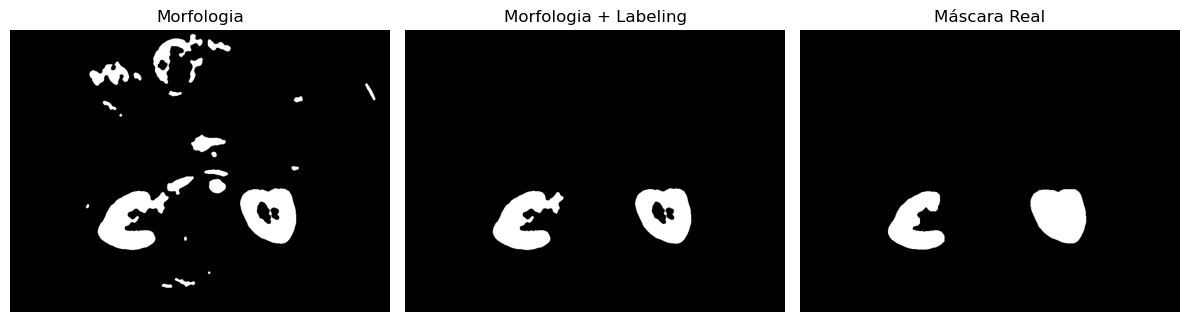

In [126]:
# ==========================================================
# OMPARAÇÃO FINAL
# ==========================================================

plt.figure(figsize=(12, 4))

# ----------------------
# MORFOLOGIA
# ----------------------
plt.subplot(1, 3, 1)
plt.imshow(mask_morfologica, cmap='gray')
plt.title('Morfologia')
plt.axis('off')


# ----------------------
# MORFOLOGIA + LABELING
# ----------------------
plt.subplot(1, 3, 2)
plt.imshow(mask_final, cmap='gray')
plt.title('Morfologia + Labeling')
plt.axis('off')


# ----------------------
# MÁSCARA REAL (GROUND TRUTH)
# ----------------------
plt.subplot(1, 3, 3)
plt.imshow(img_mask, cmap='gray')
plt.title('Máscara Real')
plt.axis('off')


plt.tight_layout()
plt.show()

#### Observações

> - O histograma da imagem permitiu identificar a gama de intensidades onde se encontram os rins, possibilitando a definição de um threshold adequado.
> - A binarização isolou regiões com intensidades semelhantes às estruturas de interesse, mas ainda com ruído e outras regiões indesejadas.
> - A aplicação de operações morfológicas (*opening* e *closing*) reduziu ruído e melhorou a continuidade das regiões segmentadas.
> - O uso de *labeling* permitiu identificar e selecionar apenas os dois maiores objetos, correspondentes aos rins, eliminando estruturas irrelevantes.
> - Comparando com a máscara real, verifica-se que a abordagem com morfologia + labeling apresenta um resultado mais próximo e consistente.
> - Diferenças residuais devem-se à escolha do threshold e à variabilidade das intensidades na imagem.

### Question 11: 
> - Improve the contrast of the kidney image using the histogram equalization technique.
> - Repeat exercise 10 for the new image. 

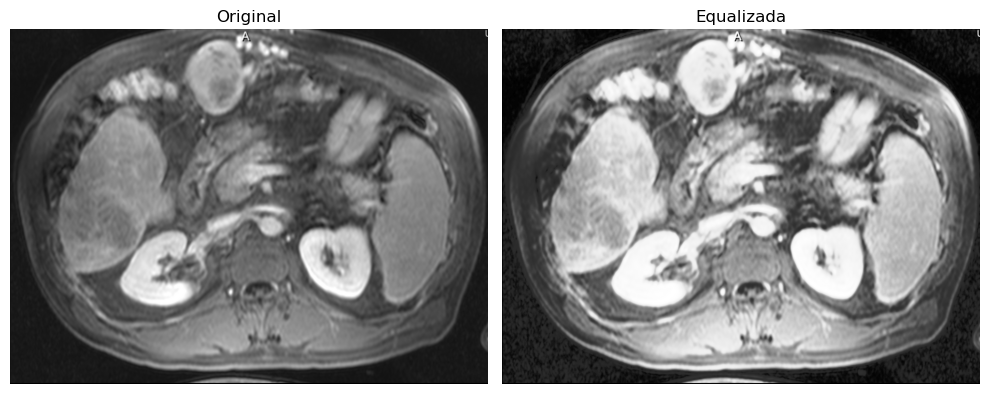

In [127]:
# ==========================================================
# EQUALIZAÇÃO DO HISTOGRAMA
# ==========================================================

from skimage import exposure

# Equalização do histograma
img_eq = exposure.equalize_hist(img_kidney)

# Converter para uint8 (0–255)
img_eq = (img_eq * 255).astype(np.uint8)


# ----------------------
# VISUALIZAÇÃO
# ----------------------

plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.imshow(img_kidney, cmap='gray')
plt.title("Original")
plt.axis('off')

# Equalizada
plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Equalizada")
plt.axis('off')

plt.tight_layout()
plt.show()

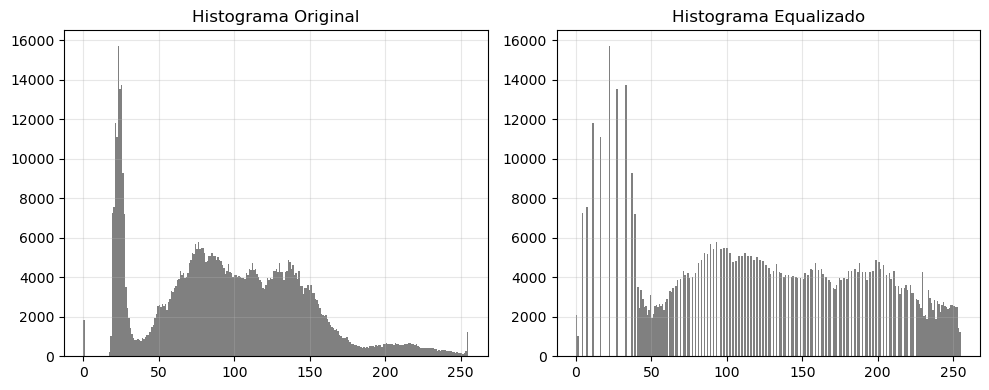

In [128]:
# ==========================================================
# HISTOGRAMA — COMPARAÇÃO
# ==========================================================

plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.hist(img_kidney.ravel(), bins=256, range=(0,255), color='gray')
plt.title("Histograma Original")
plt.grid(alpha=0.3)

# Equalizada
plt.subplot(1,2,2)
plt.hist(img_eq.ravel(), bins=256, range=(0,255), color='gray')
plt.title("Histograma Equalizado")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
# ==========================================================
# BINARIZAÇÃO (IMAGEM EQUALIZADA)
# ==========================================================

# Ajustar valores (experimentar)
thres_min = 240
thres_max = 255

mask_bin_eq = (img_eq >= thres_min) & (img_eq <= thres_max)

In [150]:
# ==========================================================
# MORFOLOGIA
# ==========================================================

mask_morph_eq = morphology.opening(mask_bin_eq, morphology.disk(3))
mask_morph_eq = morphology.closing(mask_morph_eq, morphology.disk(5))

In [151]:
# ==========================================================
# LABELING
# ==========================================================

label_eq = measure.label(mask_morph_eq)
props = measure.regionprops(label_eq)

if len(props) >= 2:
    props.sort(key=lambda x: x.area, reverse=True)

    mask_final_eq = np.zeros_like(mask_morph_eq)

    for i in range(2):
        mask_final_eq[label_eq == props[i].label] = 1
else:
    mask_final_eq = mask_morph_eq

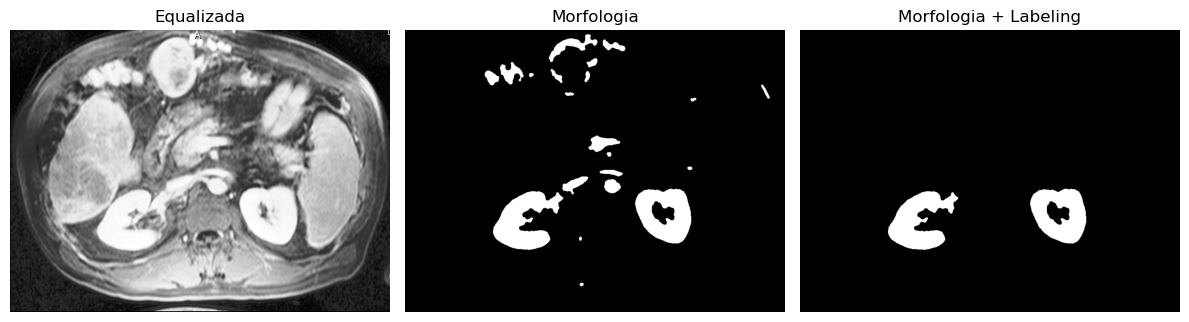

In [152]:
# ==========================================================
# RESULTADOS
# ==========================================================

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_eq, cmap='gray')
plt.title("Equalizada")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask_morph_eq, cmap='gray')
plt.title("Morfologia")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(mask_final_eq, cmap='gray')
plt.title("Morfologia + Labeling")
plt.axis('off')

plt.tight_layout()
plt.show()

#### Observações

> - A equalização do histograma aumentou o contraste global da imagem, distribuindo as intensidades de forma mais uniforme.
> - Esta uniformização dificultou inicialmente a distinção clara dos rins, devido à redução do contraste relativo entre estruturas.
> - Foi necessário ajustar o threshold de forma mais restritiva para isolar corretamente as regiões de interesse.
> - A aplicação de operações morfológicas permitiu reduzir ruído e melhorar a continuidade das regiões segmentadas.
> - O uso de *labeling* possibilitou a identificação e seleção dos dois maiores objetos, correspondentes aos rins.
> - Comparativamente à imagem original, a equalização pode melhorar ou dificultar a segmentação dependendo da escolha do threshold.